## Environment Setup


Using device: cuda
Setup complete.
Total images loaded: 60


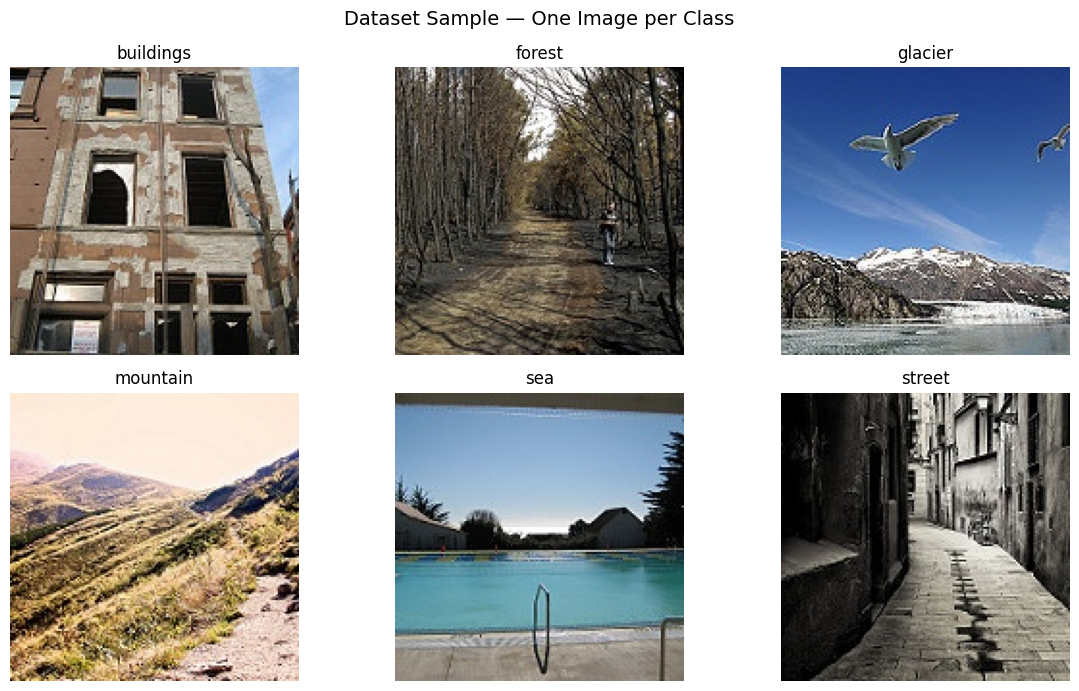

In [1]:
  import torch
  import torchvision
  from torchvision import models, transforms
  from torchvision.models import (
      ResNet18_Weights,
      MobileNet_V3_Small_Weights,
      EfficientNet_B0_Weights,                                                                                          
  )
  from PIL import Image
  import matplotlib.pyplot as plt
  import numpy as np
  import time
  import random
  import copy
  import os
  from pathlib import Path
  from sklearn.decomposition import PCA

  os.makedirs("outputs", exist_ok=True)

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print(f"Using device: {device}")                                                                                      

  DATA_DIR  = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
  TRAIN_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")
  LABELS    = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

  random.seed(42)
  print("Setup complete.")
  
  def load_images(n_per_class=10):
      image_set = []
      for label in LABELS:
          class_dir = DATA_DIR / label
          files = list(class_dir.glob("*.jpg"))
          n = min(n_per_class, len(files))
          paths = random.sample(files, n)
          for path in paths:
              img = Image.open(path).convert("RGB")
              image_set.append((img, label))
      random.shuffle(image_set)                                                                                         
      return image_set

  def load_sample_image(label):
      class_dir = DATA_DIR / label
      files = list(class_dir.glob("*.jpg"))
      img_path = random.choice(files)                                                                                   
      return Image.open(img_path).convert("RGB"), img_path.name

  image_set = load_images(n_per_class=10)
  print(f"Total images loaded: {len(image_set)}")
  
  fig, axes = plt.subplots(2, 3, figsize=(12, 7))

  shown = {}
  for img, label in image_set:
      if label not in shown:
          shown[label] = img
      if len(shown) == 6:
          break

  for label in LABELS:
      if label not in shown:
          img, _ = load_sample_image(label)
          shown[label] = img

  for ax, label in zip(axes.flatten(), LABELS):                                                                         
      ax.imshow(shown[label])
      ax.set_title(label, fontsize=12)
      ax.axis("off")

  plt.suptitle("Dataset Sample — One Image per Class", fontsize=14)                                                     
  plt.tight_layout()
  plt.savefig("outputs/dataset_sample.png", dpi=100)
  plt.show()


In [2]:
print(list(DATA_DIR.iterdir()))

[PosixPath('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain'), PosixPath('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/street'), PosixPath('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/buildings'), PosixPath('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/sea'), PosixPath('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest'), PosixPath('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/glacier')]


## Baseline Inference with ResNet18

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 216MB/s]


ResNet18 parameters: 11,689,512
Processed 60 images.
Overall mean top-1 probability: 0.4195

Mean top-1 probability by class:
  buildings   : 0.2889
  forest      : 0.2477
  glacier     : 0.4993
  mountain    : 0.5556
  sea         : 0.5710
  street      : 0.3544


/tmp/ipykernel_23/3148732924.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, patch_artist=True, labels=LABELS)


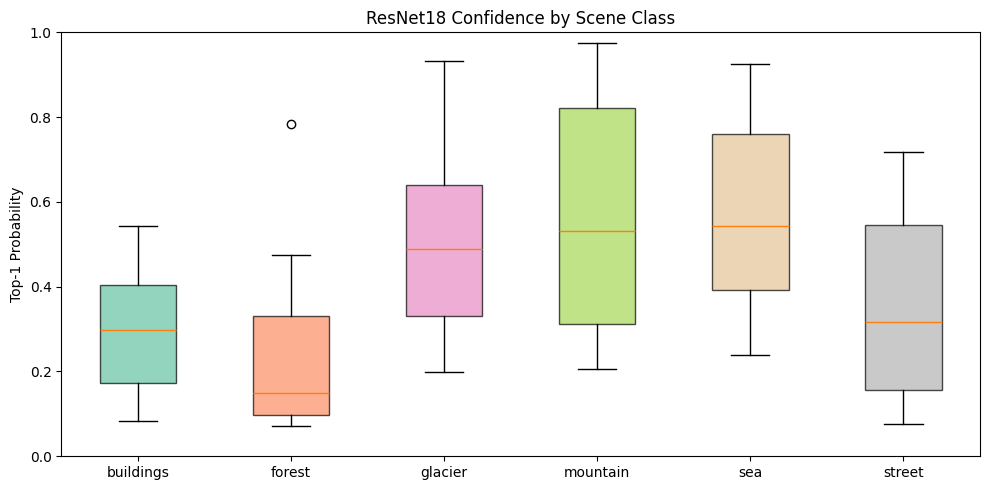

In [3]:
  resnet_weights   = ResNet18_Weights.DEFAULT
  resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
  resnet_preproc   = resnet_weights.transforms()
  imagenet_classes = resnet_weights.meta["categories"]
  
  print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")
  
  def run_inference(model, preprocess, image, device, class_labels, top_k=5):
      input_tensor = preprocess(image).unsqueeze(0).to(device)
      with torch.no_grad():
          output = model(input_tensor)
      probs = torch.nn.functional.softmax(output[0], dim=0)
      top_probs, top_indices = torch.topk(probs, top_k)
      return [(class_labels[idx.item()], prob.item())
              for idx, prob in zip(top_indices, top_probs)]

  resnet_results = []
  for img, true_label in image_set:
      preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
      resnet_results.append({
          "true_label":   true_label,
          "top1_class":   preds[0][0],
          "top1_prob":    preds[0][1],
          "top5_classes": [p[0] for p in preds],
          "top5_probs":   [p[1] for p in preds],
      })

  print(f"Processed {len(resnet_results)} images.")
  mean_conf = np.mean([r["top1_prob"] for r in resnet_results])
  print(f"Overall mean top-1 probability: {mean_conf:.4f}")

  print("\nMean top-1 probability by class:")
  for label in LABELS:
      class_probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
      print(f"  {label:12s}: {np.mean(class_probs):.4f}")

  fig, ax = plt.subplots(figsize=(10, 5))
  data_by_class = [[r["top1_prob"] for r in resnet_results if r["true_label"] == label]
                   for label in LABELS]

  bp = ax.boxplot(data_by_class, patch_artist=True, labels=LABELS)
  colors = plt.cm.Set2(np.linspace(0, 1, len(LABELS)))
  for patch, color in zip(bp["boxes"], colors):
      patch.set_facecolor(color)
      patch.set_alpha(0.7)

  ax.set_ylabel("Top-1 Probability")
  ax.set_title("ResNet18 Confidence by Scene Class")
  ax.set_ylim(0, 1)
  plt.tight_layout()
  plt.savefig("outputs/resnet18_confidence_by_class.png", dpi=100)
  plt.show()

 ## Multi-Model Comparison

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 125MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters
Inference complete for all three models.


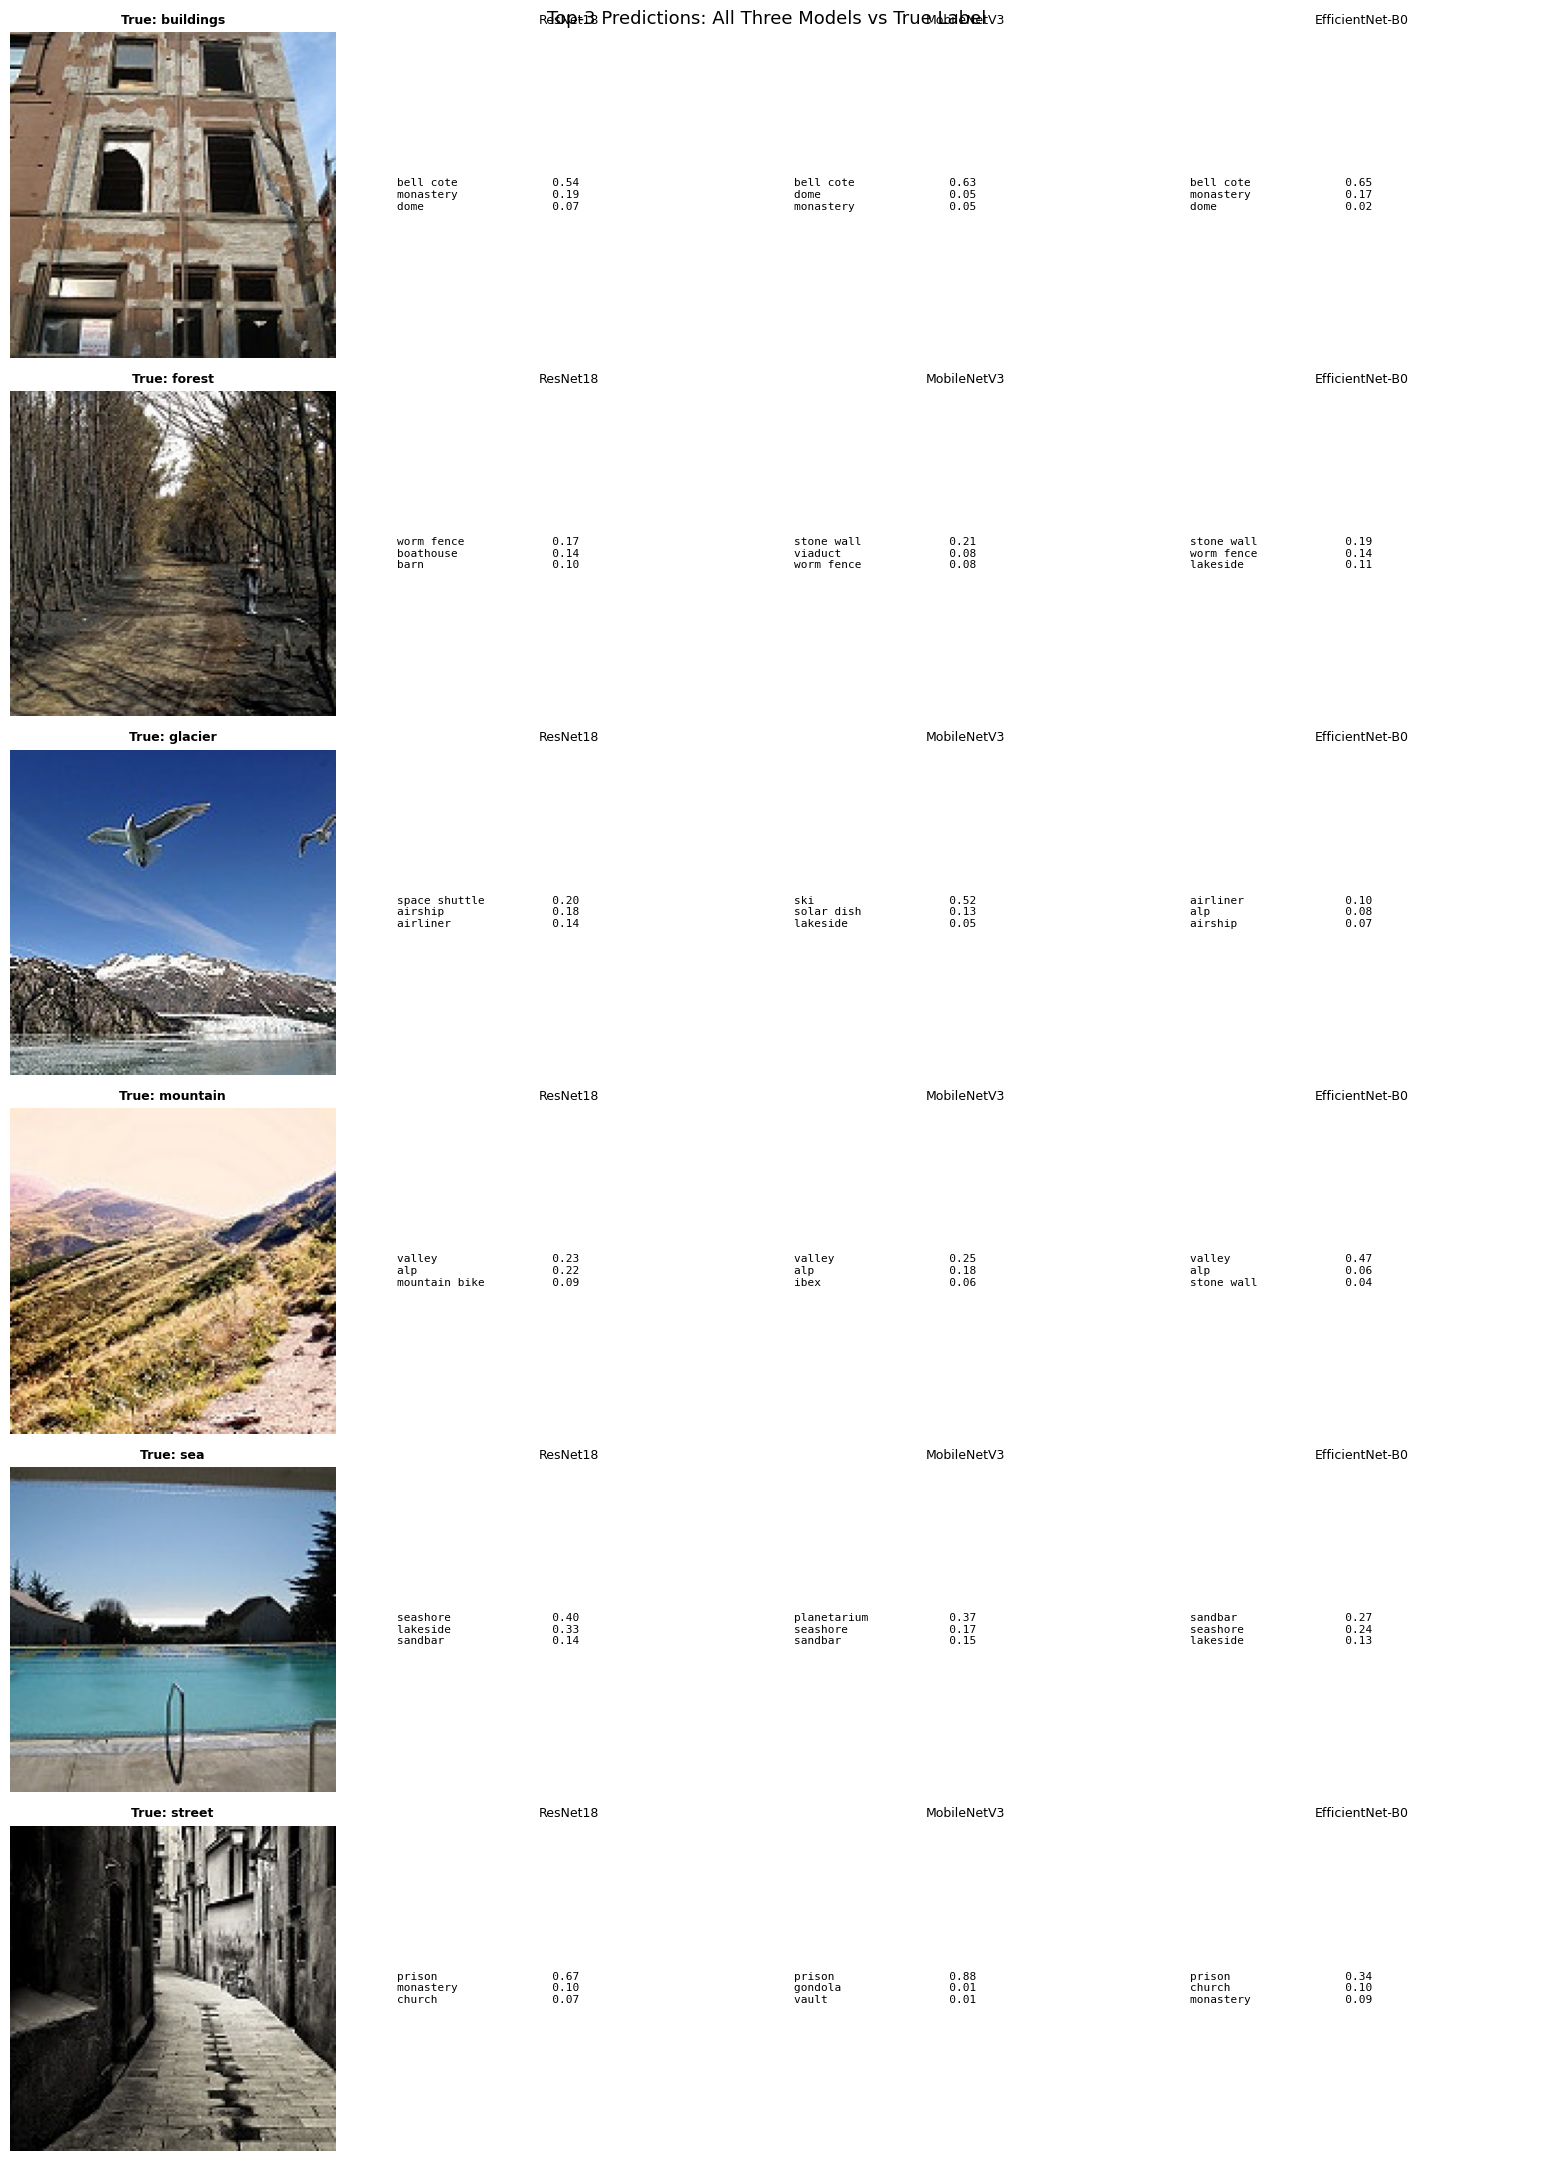

In [4]:
  mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
  mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
  mobile_preproc = mobile_weights.transforms()
  
  effnet_weights = EfficientNet_B0_Weights.DEFAULT
  efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
  effnet_preproc = effnet_weights.transforms()
  
  for name, m in [("ResNet18",          resnet),
                  ("MobileNetV3-Small", mobilenet),
                  ("EfficientNet-B0",   efficientnet)]:
      params = sum(p.numel() for p in m.parameters())
      print(f"{name:22s}  {params:>12,} parameters")

  mobilenet_results = []
  for img, true_label in image_set:
      preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
      mobilenet_results.append({
          "true_label": true_label,
          "top1_class": preds[0][0],
          "top1_prob":  preds[0][1],
          "top5_classes": [p[0] for p in preds],
      })

  effnet_results = []
  for img, true_label in image_set:
      preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)                                
      effnet_results.append({
          "true_label": true_label,
          "top1_class": preds[0][0],
          "top1_prob":  preds[0][1],
          "top5_classes": [p[0] for p in preds],
      })

  print("Inference complete for all three models.")
  
  fig, axes = plt.subplots(6, 4, figsize=(16, 22))

  sample_per_class = {}
  for img, label in image_set:
      if label not in sample_per_class:
          sample_per_class[label] = img
      if len(sample_per_class) == 6:
          break

  for row, label in enumerate(LABELS):                                                                                  
      img = sample_per_class[label]
      axes[row, 0].imshow(img)
      axes[row, 0].set_title(f"True: {label}", fontsize=9, fontweight="bold")
      axes[row, 0].axis("off")

      for col, (model_obj, preproc, name) in enumerate([
          (resnet,       resnet_preproc,  "ResNet18"),
          (mobilenet,    mobile_preproc,  "MobileNetV3"),
          (efficientnet, effnet_preproc,  "EfficientNet-B0"),
      ]):
          preds = run_inference(model_obj, preproc, img, device, imagenet_classes, top_k=3)                             
          pred_text = "\n".join([f"{p[0][:22]:22s} {p[1]:.2f}" for p in preds])
          axes[row, col+1].text(0.05, 0.5, pred_text,
                                transform=axes[row, col+1].transAxes,
                                fontsize=8, verticalalignment="center", family="monospace")
          axes[row, col+1].set_title(name, fontsize=9)
          axes[row, col+1].axis("off")

  plt.suptitle("Top-3 Predictions: All Three Models vs True Label", fontsize=13)
  plt.tight_layout()
  plt.savefig("outputs/model_comparison_grid.png", dpi=100, bbox_inches="tight")
  plt.show()

## Speed Benchmarking

ResNet18:           4.06 ms/image
MobileNetV3-Small:  6.63 ms/image
EfficientNet-B0:    9.53 ms/image


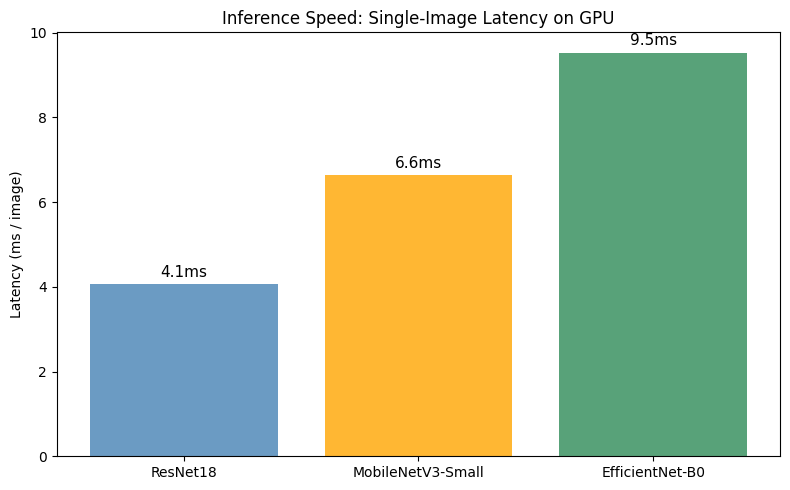


Model                    Parameters    ms/image
------------------------------------------------
ResNet18                     11.7M        4.06
MobileNetV3-Small             2.5M        6.63
EfficientNet-B0               5.3M        9.53


In [5]:
 def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
      for img, _ in image_set[:n_warmup]:
          tensor = preprocess(img).unsqueeze(0).to(device)
          with torch.no_grad():
              _ = model(tensor)
              
      torch.cuda.synchronize()
      start = time.time()
      
      for img, _ in image_set:
          tensor = preprocess(img).unsqueeze(0).to(device)                                                              
          with torch.no_grad():
              _ = model(tensor)
              
      torch.cuda.synchronize()
      elapsed = time.time() - start
      return (elapsed / len(image_set)) * 1000                                                                          
      
resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)
  
print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

model_names_plot = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies        = [resnet_ms, mobile_ms, effnet_ms]
params_millions  = [
      sum(p.numel() for p in resnet.parameters()) / 1e6,
      sum(p.numel() for p in mobilenet.parameters()) / 1e6,
      sum(p.numel() for p in efficientnet.parameters()) / 1e6,
  ]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names_plot, latencies,                                                                            
                color=["steelblue", "orange", "seagreen"], alpha=0.8)
ax.set_ylabel("Latency (ms / image)")
ax.set_title("Inference Speed: Single-Image Latency on GPU")
for bar, lat in zip(bars, latencies):
      ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f"{lat:.1f}ms", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/inference_speed.png", dpi=100)
plt.show()

print(f"\n{'Model':<22} {'Parameters':>12}  {'ms/image':>10}")
print("-" * 48)
for name, params, lat in zip(model_names_plot, params_millions, latencies):
   print(f"{name:<22} {params:>10.1f}M  {lat:>10.2f}")

## Feature Extraction + PCA

Feature matrix shape: (60, 512)


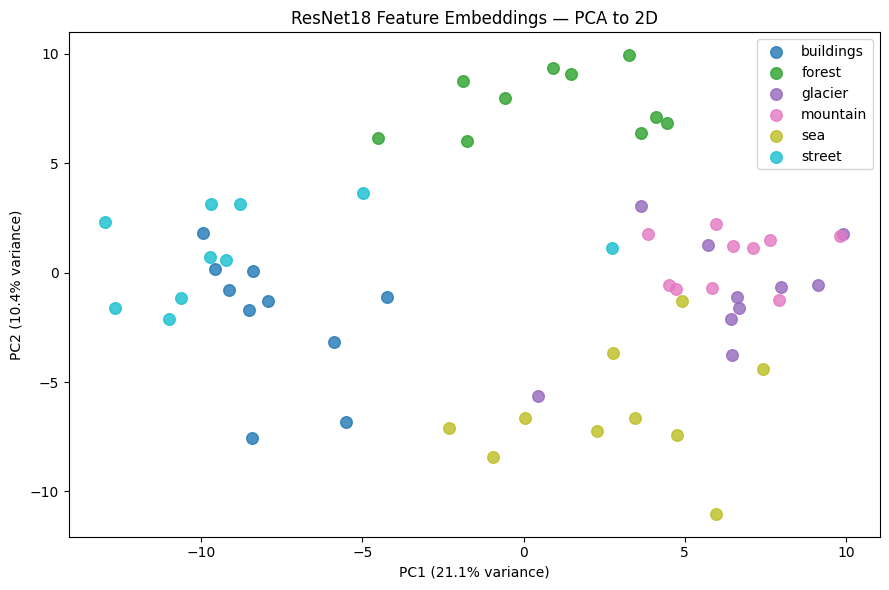

In [6]:
  feature_extractor = copy.deepcopy(resnet)
  feature_extractor.fc = torch.nn.Identity()
  feature_extractor    = feature_extractor.to(device).eval()
  
  def extract_features(model, preprocess, image, device):
      tensor = preprocess(image).unsqueeze(0).to(device)
      with torch.no_grad():
          features = model(tensor)
      return features.squeeze().cpu().numpy()
      
  feature_vectors = []
  true_labels     = []                                                                                                  
  
  for img, label in image_set:
      feat = extract_features(feature_extractor, resnet_preproc, img, device)
      feature_vectors.append(feat)
      true_labels.append(label)
      
  feature_matrix = np.array(feature_vectors)
  print(f"Feature matrix shape: {feature_matrix.shape}")                                                                

  pca         = PCA(n_components=2)
  features_2d = pca.fit_transform(feature_matrix)

  fig, ax = plt.subplots(figsize=(9, 6))
  colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

  for i, label in enumerate(LABELS):
      mask = [l == label for l in true_labels]
      ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                 label=label, color=colors[i], s=70, alpha=0.8)

  ax.legend(fontsize=10)
  ax.set_title("ResNet18 Feature Embeddings — PCA to 2D")
  ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
  ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
  plt.tight_layout()
  plt.savefig("outputs/feature_embeddings.png", dpi=100)
  plt.show()

## Summary 

In [7]:
  print("=" * 60)
  print("MODEL COMPARISON SUMMARY")
  print("=" * 60)
  
  for name, params, lat, results in [
      ("ResNet18",          params_millions[0], resnet_ms,  resnet_results),
      ("MobileNetV3-Small", params_millions[1], mobile_ms,  mobilenet_results),
      ("EfficientNet-B0",   params_millions[2], effnet_ms,  effnet_results),
  ]:  
      mean_conf = np.mean([r["top1_prob"] for r in results])
      print(f"\n{name}")
      print(f"  Parameters:       {params:.1f}M")
      print(f"  Latency:          {lat:.2f} ms/image")
      print(f"  Mean confidence:  {mean_conf:.4f}")

MODEL COMPARISON SUMMARY

ResNet18
  Parameters:       11.7M
  Latency:          4.06 ms/image
  Mean confidence:  0.4195

MobileNetV3-Small
  Parameters:       2.5M
  Latency:          6.63 ms/image
  Mean confidence:  0.4177

EfficientNet-B0
  Parameters:       5.3M
  Latency:          9.53 ms/image
  Mean confidence:  0.3574
